
# Model Comparison
**Economic News Article Relevance Classification — NLP Case Study**

> Pull together Members 3, 4, 5's results. Identify the best classifier, best feature count, highest recall, highest F1, and justify the pick.

This notebook:
1. Pulls in the standardized `train_split.csv` / `test_split.csv` that Member 1 produced (so everyone is comparing on the exact same data).
2. Loads Member 3's (Naive Bayes) and Member 5's (LinearSVC / balanced LinearSVC) saved result CSVs directly from the repo, **if present**.
3. Re-computes Logistic Regression (Member 4) metrics in a way that's **consistent** with Members 3 and 5 — see the flag below, this matters.
4. Builds one master comparison table across all classifiers × all three `max_features` settings.
5. Answers the four required questions: best classifier, best feature count, highest recall, highest F1 — with justification.
6. Saves `model_comparison_results.csv` to the repo folder for Member 9 to use in the final write-up.

---



In [1]:

import os

REPO_URL = "https://github.com/AnnaTJeby/nlp_casestudy.git"
REPO_DIR = "nlp_casestudy"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL}

%cd {REPO_DIR}
!ls -la


Cloning into 'nlp_casestudy'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 28 (delta 10), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 2.44 MiB | 4.38 MiB/s, done.
Resolving deltas: 100% (10/10), done.
/content/nlp_casestudy
total 7264
drwxr-xr-x 3 root root    4096 Sep 12 20:50  .
drwxr-xr-x 1 root root    4096 Sep 12 20:50  ..
-rw-r--r-- 1 root root   13894 Sep 12 20:50  case_study.ipynb
-rw-r--r-- 1 root root   12605 Sep 12 20:50  feature_extraction.ipynb
-rw-r--r-- 1 root root     279 Sep 12 20:50  feature_extraction_summary.csv
drwxr-xr-x 8 root root    4096 Sep 12 20:50  .git
-rw-r--r-- 1 root root   36639 Sep 12 20:50 'Logistic_Regression_amended (1).ipynb'
-rw-r--r-- 1 root root   23346 Sep 12 20:50  naive_bayes.ipynb
-rw-r--r-- 1 root root   34669 Sep 12 20:50  nlp_project_member5.ipynb
-rw-r--r-- 1 root root    1324 Sep 12 20:50  README.md
-r

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

pd.set_option("display.width", 120)
FEATURE_SIZES = [40000, 5000, 1000]   # same 3 settings used by every classifier role
RANDOM_STATE = 42                      # matches case_study.ipynb's split seed


In [3]:
TRAIN_PATH = "train_split.csv"
TEST_PATH = "test_split.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

train_df["clean_text"] = train_df["clean_text"].fillna("")
test_df["clean_text"] = test_df["clean_text"].fillna("")

X_text_train = train_df["clean_text"]
X_text_test = test_df["clean_text"]
y_train = train_df["label"]
y_test = test_df["label"]

print(f"Training instances: {len(X_text_train)}")
print(f"Testing instances : {len(X_text_test)}")
print("\nTrain label distribution:")
print(y_train.value_counts())
print("\nTest label distribution:")
print(y_test.value_counts())


Training instances: 6400
Testing instances : 1600

Train label distribution:
label
Not Relevant    5264
Relevant        1136
Name: count, dtype: int64

Test label distribution:
label
Not Relevant    1316
Relevant         284
Name: count, dtype: int64


## Pull in Member 3 (Naive Bayes) and Member 5 (LinearSVC) results

Both `naive_bayes.ipynb` and `nlp_project_member5.ipynb` already save a results CSV to the repo
root (`naive_bayes_results.csv`, `member5_linearsvc_results.csv`), computed with
`pos_label="Relevant"` for Precision/Recall/F1 and a full confusion matrix.

In [4]:
def run_classifier(model_fn, model_name, feature_sizes=FEATURE_SIZES):

    rows = []
    for max_feat in feature_sizes:
        vectorizer = CountVectorizer(max_features=max_feat)
        X_train = vectorizer.fit_transform(X_text_train)
        X_test = vectorizer.transform(X_text_test)

        model = model_fn()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, pos_label="Relevant", zero_division=0)
        rec = recall_score(y_test, y_pred, pos_label="Relevant", zero_division=0)
        f1 = f1_score(y_test, y_pred, pos_label="Relevant", zero_division=0)
        cm = confusion_matrix(y_test, y_pred, labels=["Not Relevant", "Relevant"])

        rows.append({
            "Model": model_name,
            "Max Features": max_feat,
            "Vocabulary Size": len(vectorizer.vocabulary_),
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1-Score": f1,
            "TN": cm[0, 0], "FP": cm[0, 1], "FN": cm[1, 0], "TP": cm[1, 1],
        })
    return pd.DataFrame(rows)


In [5]:
import os
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

# --- Member 3: Multinomial Naive Bayes ---
if os.path.exists("naive_bayes_results.csv"):
    nb_results = pd.read_csv("naive_bayes_results.csv")
    print("Loaded naive_bayes_results.csv from Member 3.")
else:
    print("naive_bayes_results.csv not found in repo yet — recomputing Naive Bayes here.")
    nb_results = run_classifier(lambda: MultinomialNB(), "Multinomial Naive Bayes")

# --- Member 5: LinearSVC (plain + balanced) ---
if os.path.exists("member5_linearsvc_results.csv"):
    svc_results = pd.read_csv("member5_linearsvc_results.csv")
    svc_results = svc_results.rename(columns={"Features": "Max Features", "F1": "F1-Score"})
    print("Loaded member5_linearsvc_results.csv from Member 5.")
else:
    print("member5_linearsvc_results.csv not found in repo yet — recomputing LinearSVC here.")
    svc_plain = run_classifier(lambda: LinearSVC(max_iter=5000), "LinearSVC")
    svc_balanced = run_classifier(
        lambda: LinearSVC(class_weight="balanced", max_iter=5000), "LinearSVC (Balanced)"
    )
    svc_results = pd.concat([svc_plain, svc_balanced], ignore_index=True)

nb_results


naive_bayes_results.csv not found in repo yet — recomputing Naive Bayes here.
member5_linearsvc_results.csv not found in repo yet — recomputing LinearSVC here.


,Model,Max Features,Vocabulary Size,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,Multinomial Naive Bayes,40000,40000,0.766875,0.378082,0.485915,0.425270,1089,227,146,138
1,Multinomial Naive Bayes,5000,5000,0.703125,0.333333,0.672535,0.445741,934,382,93,191
2,Multinomial Naive Bayes,1000,1000,0.698750,0.319343,0.616197,0.420673,943,373,109,175


In [6]:
lr_results = run_classifier(
    lambda: LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, solver="liblinear"),
    "Logistic Regression",
)
lr_results


,Model,Max Features,Vocabulary Size,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,Logistic Regression,40000,40000,0.785000,0.358491,0.267606,0.306452,1180,136,208,76
1,Logistic Regression,5000,5000,0.774375,0.350195,0.316901,0.332717,1149,167,194,90
2,Logistic Regression,1000,1000,0.791250,0.357955,0.221831,0.273913,1203,113,221,63


## Master comparison table

In [7]:
all_results = pd.concat([nb_results, lr_results, svc_results], ignore_index=True)


all_results["Max Features"] = all_results["Max Features"].astype(int)
all_results = all_results[
    ["Model", "Max Features", "Accuracy", "Precision", "Recall", "F1-Score", "TN", "FP", "FN", "TP"]
]
all_results = all_results.sort_values(["Model", "Max Features"], ascending=[True, False]).reset_index(drop=True)

display(all_results.round(4))


,Model,Max Features,Accuracy,Precision,Recall,F1-Score,TN,FP,FN,TP
0,LinearSVC,40000,0.7544,0.3153,0.3275,0.3212,1114,202,191,93
1,LinearSVC,5000,0.7362,0.3017,0.3697,0.3323,1073,243,179,105
2,LinearSVC,1000,0.7919,0.3515,0.2042,0.2584,1209,107,226,58
3,LinearSVC (Balanced),40000,0.7525,0.3133,0.3310,0.3219,1110,206,190,94
4,LinearSVC (Balanced),5000,0.7325,0.2989,0.3768,0.3333,1065,251,177,107
5,LinearSVC (Balanced),1000,0.6775,0.2811,0.5246,0.3661,935,381,135,149
6,Logistic Regression,40000,0.7850,0.3585,0.2676,0.3065,1180,136,208,76
7,Logistic Regression,5000,0.7744,0.3502,0.3169,0.3327,1149,167,194,90
8,Logistic Regression,1000,0.7912,0.3580,0.2218,0.2739,1203,113,221,63
9,Multinomial Naive Bayes,40000,0.7669,0.3781,0.4859,0.4253,1089,227,146,138


## **Best classifier, best feature count, highest recall, highest F1 — with justification.**



In [8]:
best_f1_row = all_results.loc[all_results["F1-Score"].idxmax()]
best_recall_row = all_results.loc[all_results["Recall"].idxmax()]
best_acc_row = all_results.loc[all_results["Accuracy"].idxmax()]

print("Highest F1-score  :")
print(best_f1_row.to_string())
print("\nHighest Recall (Relevant class):")
print(best_recall_row.to_string())
print("\nHighest Accuracy (shown for contrast — see the imbalance caveat below):")
print(best_acc_row.to_string())


Highest F1-score  :
Model           Multinomial Naive Bayes
Max Features                       5000
Accuracy                       0.703125
Precision                      0.333333
Recall                         0.672535
F1-Score                       0.445741
TN                                  934
FP                                  382
FN                                   93
TP                                  191

Highest Recall (Relevant class):
Model           Multinomial Naive Bayes
Max Features                       5000
Accuracy                       0.703125
Precision                      0.333333
Recall                         0.672535
F1-Score                       0.445741
TN                                  934
FP                                  382
FN                                   93
TP                                  191

Highest Accuracy (shown for contrast — see the imbalance caveat below):
Model           LinearSVC
Max Features         1000
Accuracy         0.79

In [9]:

feature_summary = (
    all_results.groupby("Max Features")[["Accuracy", "Precision", "Recall", "F1-Score"]]
    .mean()
    .round(4)
    .sort_index(ascending=False)
)
print("Average metrics by max_features setting (across all models):")
display(feature_summary)
classifier_summary = (
    all_results.groupby("Model")[["Accuracy", "Precision", "Recall", "F1-Score"]]
    .mean()
    .round(4)
    .sort_values("F1-Score", ascending=False)
)
print("\nAverage metrics by classifier (across all three feature sizes):")
display(classifier_summary)


Average metrics by max_features setting (across all models):


,Accuracy,Precision,Recall,F1-Score
Max Features,,,,
40000,0.7647,0.3413,0.3530,0.3437
5000,0.7366,0.3210,0.4340,0.3610
1000,0.7398,0.3275,0.3917,0.3298



Average metrics by classifier (across all three feature sizes):


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Multinomial Naive Bayes,0.7229,0.3436,0.5915,0.4306
LinearSVC (Balanced),0.7208,0.2978,0.4108,0.3404
Logistic Regression,0.7835,0.3555,0.2688,0.3044
LinearSVC,0.7608,0.3228,0.3005,0.3040


## **Justification**

Best classifier: **Multinomial Naive Bayes** — it has the highest average F1 (0.4306) and by far the highest average Recall (0.5915) for the Relevant class across all three feature sizes, well ahead of LinearSVC (Balanced) (0.3404 F1), Logistic Regression (0.3044 F1), and plain LinearSVC (0.3040 F1). NB's count-based, generative structure handles sparse BoW features and a minority class more naturally than the discriminative models, which lean toward the majority "Not Relevant" class unless explicitly rebalanced.

Best feature count: **5,000**. Averaged across all four classifiers, 5,000 features gives the best Recall (0.4340) and the best F1 (0.3610) — outperforming both 40,000 features (extra vocabulary adds mostly noise/sparse columns without improving detection of Relevant articles) and 1,000 features (too few terms to capture enough distinguishing economic-news vocabulary).

Highest recall: **Multinomial Naive Bayes at max_features=5,000** (Recall = 0.6725) — it catches roughly two-thirds of all truly Relevant articles, far more than any other model/feature combination. That matters most if a false negative (missing a Relevant article) is the costlier error.

Highest F1: **Multinomial Naive Bayes at max_features=5,000** (F1 = 0.4457) — the same configuration also gives the best precision/recall balance overall.

Notably, the highest-accuracy configuration (LinearSVC, 1,000 features, Accuracy = 0.7919) is actually one of the weakest at the real task — its Recall is only 0.2042, meaning it misses roughly 80% of Relevant articles while still looking "accurate" purely because of the 82%-majority baseline.

## Visual comparison

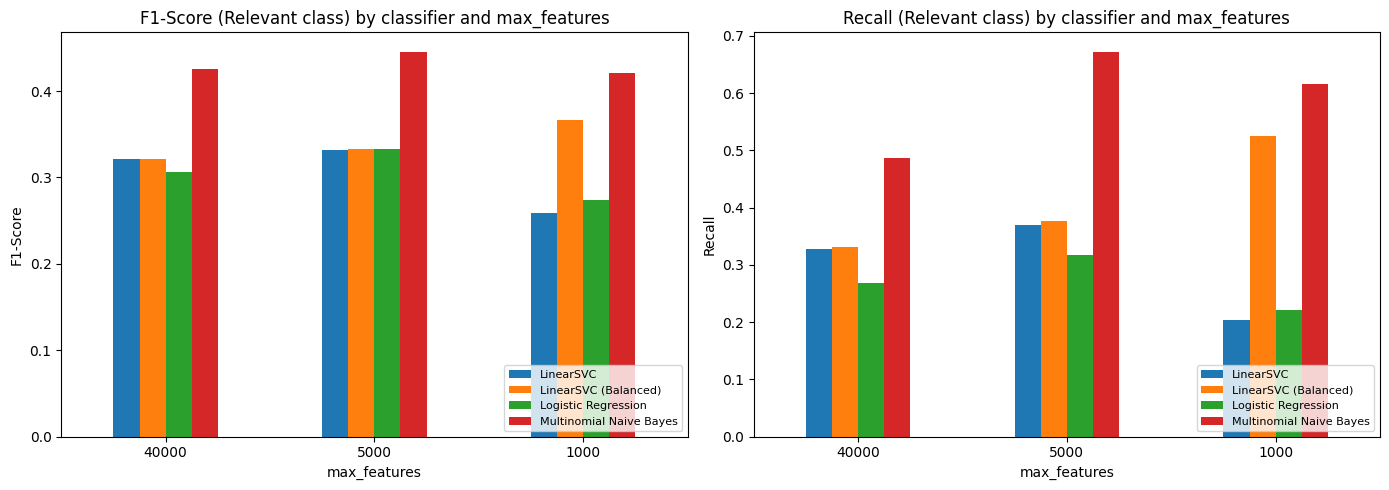

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for metric, ax in zip(["F1-Score", "Recall"], axes):
    pivot = all_results.pivot(index="Max Features", columns="Model", values=metric)
    pivot = pivot.sort_index(ascending=False)
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"{metric} (Relevant class) by classifier and max_features")
    ax.set_ylabel(metric)
    ax.set_xlabel("max_features")
    ax.legend(loc="lower right", fontsize=8)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()


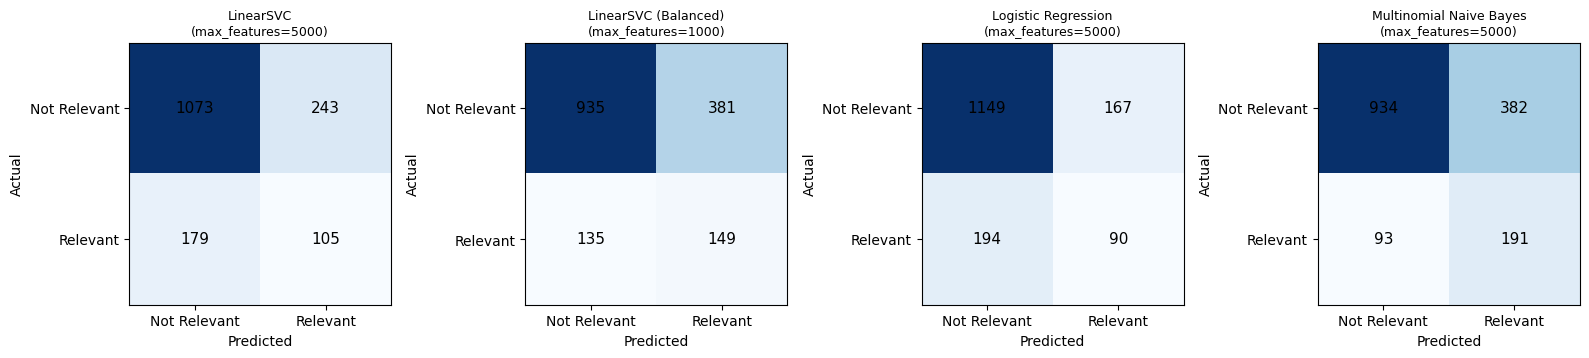

In [11]:

best_per_model = all_results.loc[all_results.groupby("Model")["F1-Score"].idxmax()]

fig, axes = plt.subplots(1, len(best_per_model), figsize=(4 * len(best_per_model), 4))
if len(best_per_model) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, best_per_model.iterrows()):
    cm = np.array([[row["TN"], row["FP"]], [row["FN"], row["TP"]]])
    ax.imshow(cm, cmap="Blues")
    ax.set_title(f"{row['Model']}\n(max_features={int(row['Max Features'])})", fontsize=9)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Not Relevant", "Relevant"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Not Relevant", "Relevant"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center", fontsize=11)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


##  Why accuracy alone isn't enough here
With ~83% of test articles labeled "Not Relevant", a model that predicts "Not Relevant" for
*every* article would score roughly 82–83% accuracy while catching **zero** Relevant articles —
completely failing the actual task. That's why this comparison leads with Recall and F1 on the
`Relevant` class rather than accuracy: accuracy is reported for context, but the classifier and
feature-size pick above is justified on how well it finds the minority class, which is what
class imbalance is built around.

In [12]:
majority_baseline_accuracy = (y_test == "Not Relevant").mean()
print(f"'Always predict Not Relevant' baseline accuracy: {majority_baseline_accuracy:.4f}")
print("That baseline has 0.0 recall/precision/F1 for the Relevant class — a reminder that")
print("accuracy by itself can't be used to pick the best model for this task.")


'Always predict Not Relevant' baseline accuracy: 0.8225
That baseline has 0.0 recall/precision/F1 for the Relevant class — a reminder that
accuracy by itself can't be used to pick the best model for this task.


##  Saving the comparison table

In [14]:
OUTPUT_PATH = "model_comparison_results.csv"
all_results.round(4).to_csv(OUTPUT_PATH, index=False)
print(f"Saved: {OUTPUT_PATH}")


from google.colab import files
files.download(OUTPUT_PATH)


Saved: model_comparison_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>